## Importy

In [1]:
import os
import re
from scripts.cvrp_ilp import solve_cvrp_ilp as solve_cvrp_ilp_basic
from scripts.cvrp_ilp_opt import solve_cvrp_ilp as solve_cvrp_ilp_opt
from scripts.cvrp_ilp_warm import solve_cvrp_ilp as solve_cvrp_ilp_warm
from scripts.cvrp_genetic import solve_cvrp_ga
from scripts.cvrp_hybrid import solve_cvrp_hybrid

from scripts.plot_utils import plot_cbc_log, plot_ga_log

## Funkcje Pomocnicze

In [2]:
def get_optimal_cost(vrp_filepath):
    sol_filepath = vrp_filepath.replace('.vrp', '.sol')
    if os.path.exists(sol_filepath):
        with open(sol_filepath, 'r') as f:
            for line in f:
                if line.startswith('Cost'):
                    match = re.search(r'Cost\s+(\d+)', line)
                    if match:
                        return float(match.group(1))
    return None


def run_experiments(instances, solver_function, **kwargs):
    for inst in instances:
        if os.path.exists(inst):
            try:
                opt_cost = get_optimal_cost(inst)
                solver_function(inst, **kwargs)
                
                if solver_function.__name__ == 'solve_cvrp_ga':
                    plot_ga_log(optimum_cost=opt_cost)
                    
                else:
                    plot_cbc_log(optimum_cost=opt_cost)
                
            except Exception as e:
                print(f"Błąd podczas analizy {inst}: {e}")
        else:
            print(f"Plik {inst} nie istnieje!")

## Instancje

In [3]:
instances = [
    os.path.join('data', 'E', 'E-n23-k3.vrp')
]

## Algorytm ILP Klasyczny

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Uruchamianie solvera
Czas wykonania: 9.74 s
Status: Optimal
Minimal tour: 623.0
Routes: [[1, 5, 6, 9, 8, 10, 14, 13, 1], [1, 7, 2, 4, 3, 17, 16, 15, 18, 23, 21, 20, 19, 1], [1, 12, 11, 22, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


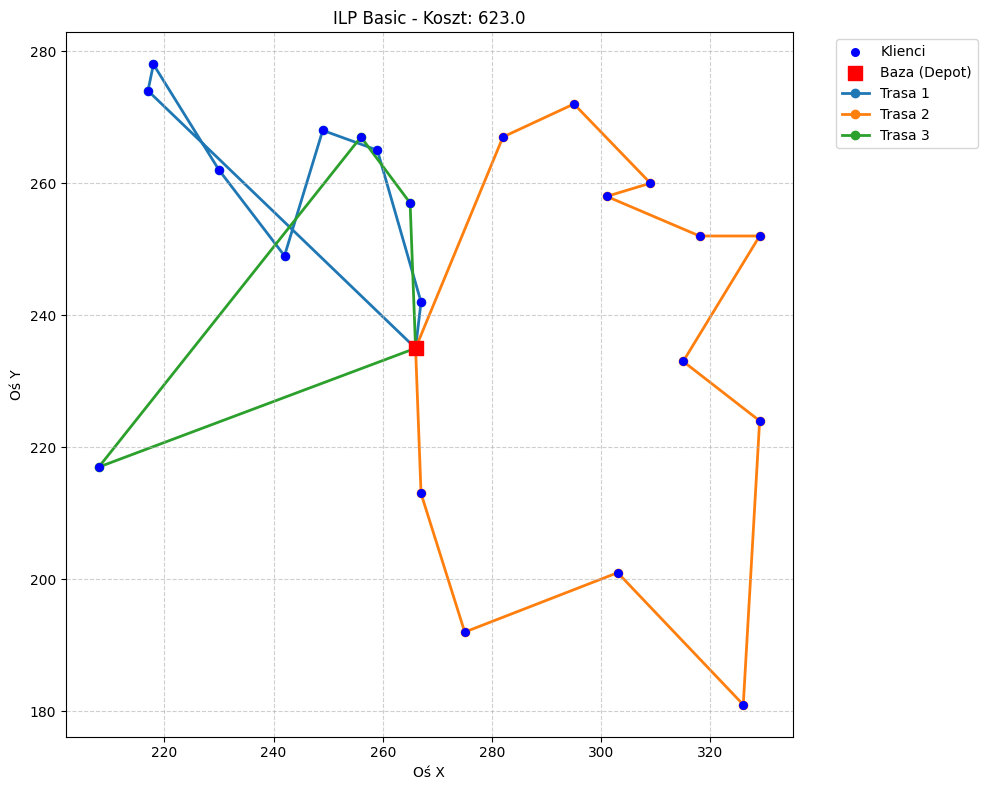

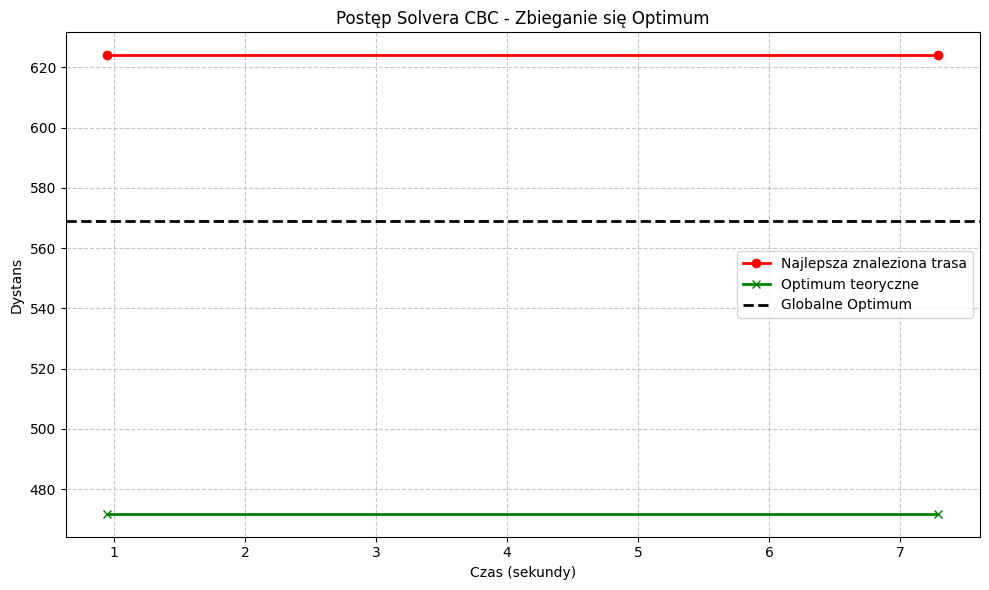

In [4]:
run_experiments(instances, solve_cvrp_ilp_basic, time_limit=10)

## Algorytm ILP z Optymalizacjami

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Uruchamianie solvera
Czas wykonania: 9.97 s
Status: Optimal
Minimal tour: 569.0
Routes: [[1, 8, 10, 9, 6, 5, 22, 1], [1, 11, 14, 1], [1, 13, 12, 7, 2, 3, 4, 17, 16, 15, 18, 23, 21, 20, 19, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


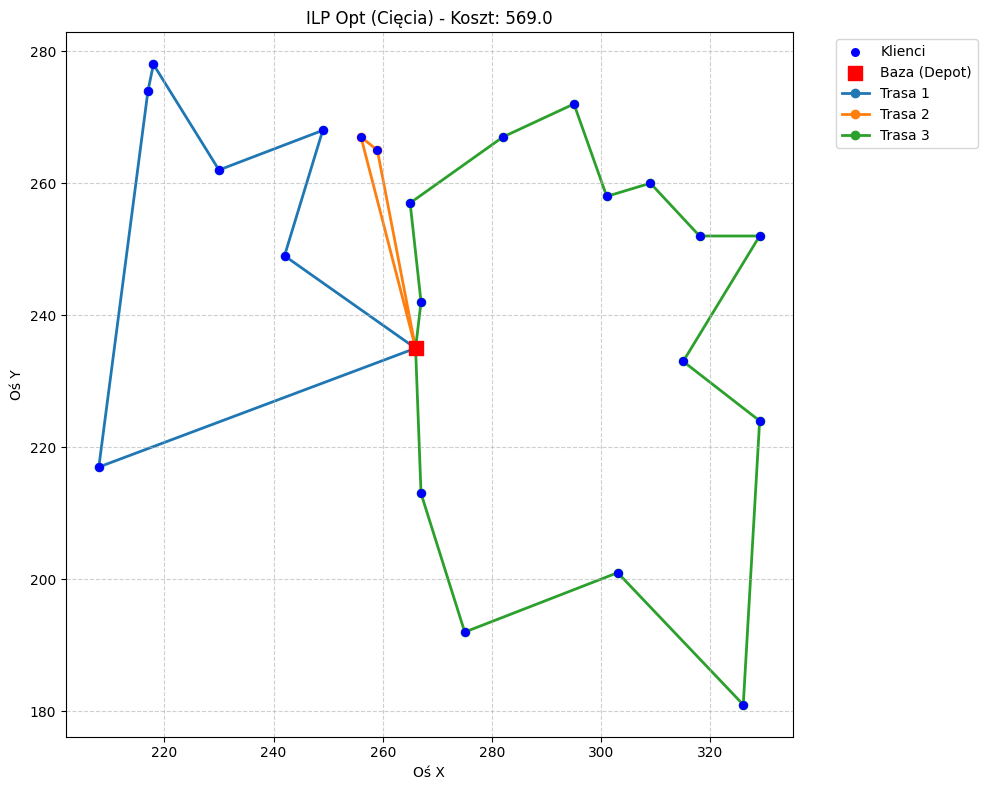

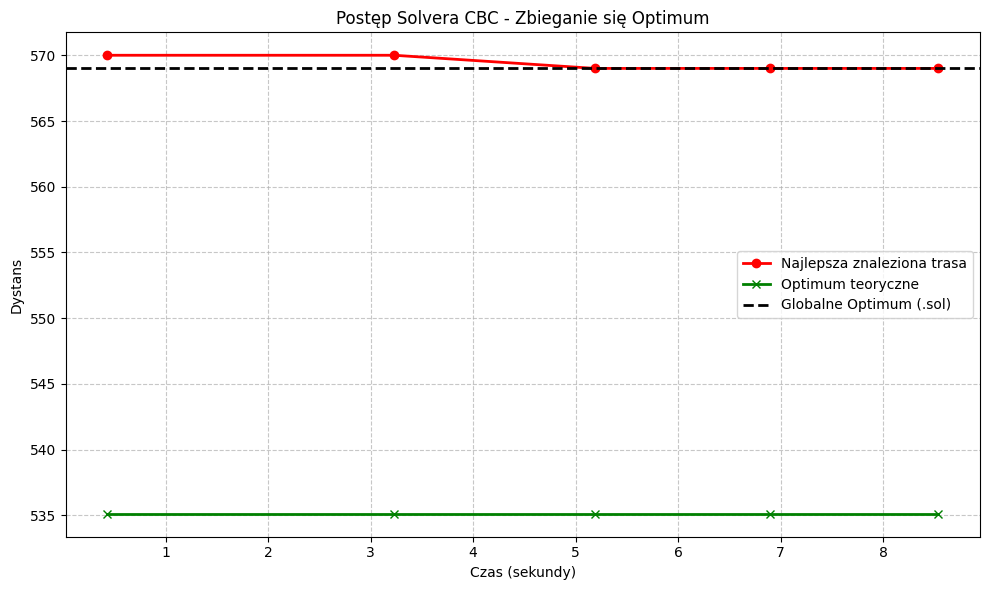

In [11]:
run_experiments(instances, solve_cvrp_ilp_opt, time_limit=10)

## Algorytm ILP z Optymalizacjami i 'Warm Start NN'

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Uruchamianie solvera
Czas wykonania: 26.52 s
Status: Optimal
Minimal tour: 569.0
Routes: [[1, 8, 10, 9, 6, 5, 22, 1], [1, 14, 11, 1], [1, 19, 20, 21, 23, 18, 15, 16, 17, 4, 3, 2, 7, 12, 13, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


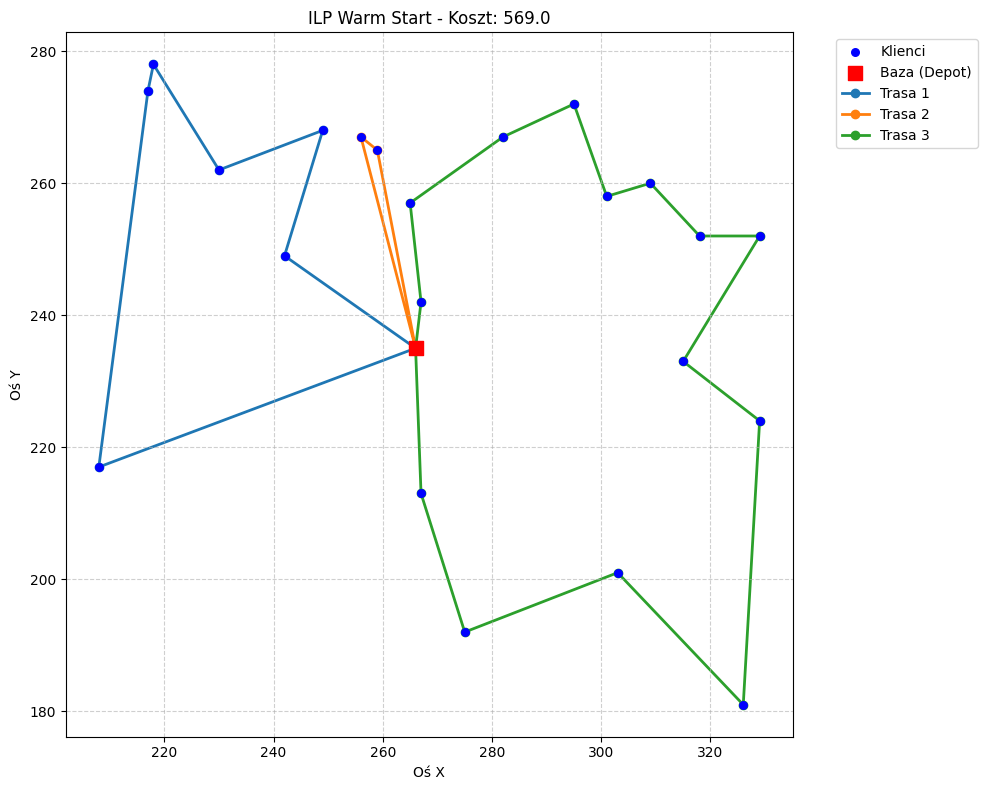

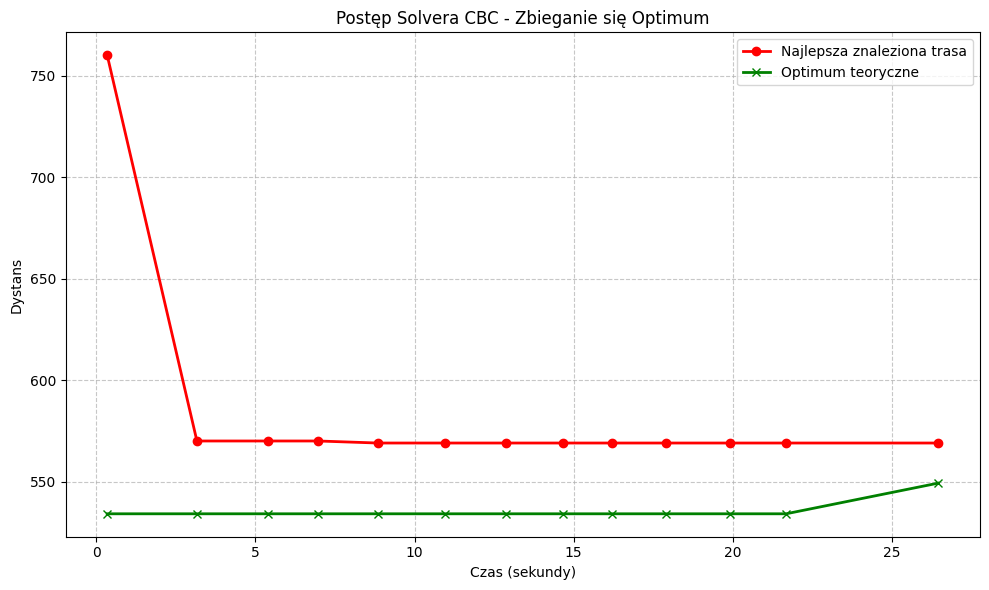

In [6]:
run_experiments(instances, solve_cvrp_ilp_warm, time_limit=30)

## Algorytm Genetyczny

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Parametry GA: Populacja=400, Pokolenia=500, Limit czasu=40s
Uruchamianie algorytmu genetycznego
Czas wykonania: 4.00 s
Minimal tour: 569
Routes: [[1, 19, 20, 21, 23, 18, 15, 16, 17, 4, 3, 2, 7, 12, 13, 1], [1, 11, 14, 1], [1, 22, 5, 6, 9, 10, 8, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


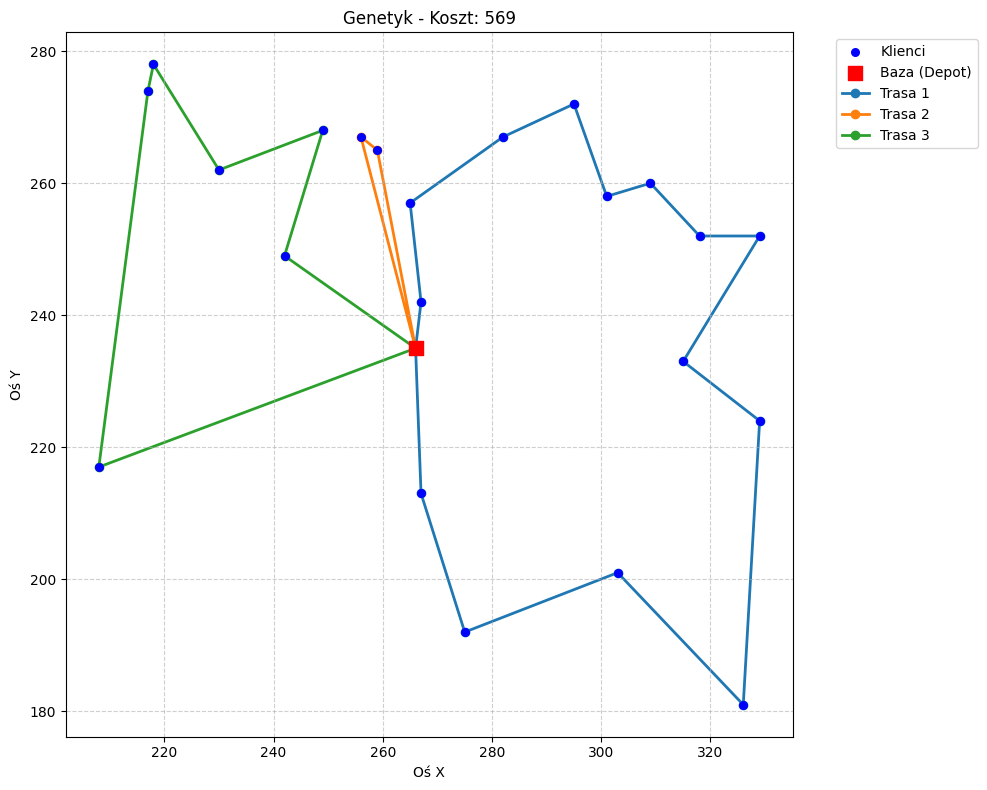

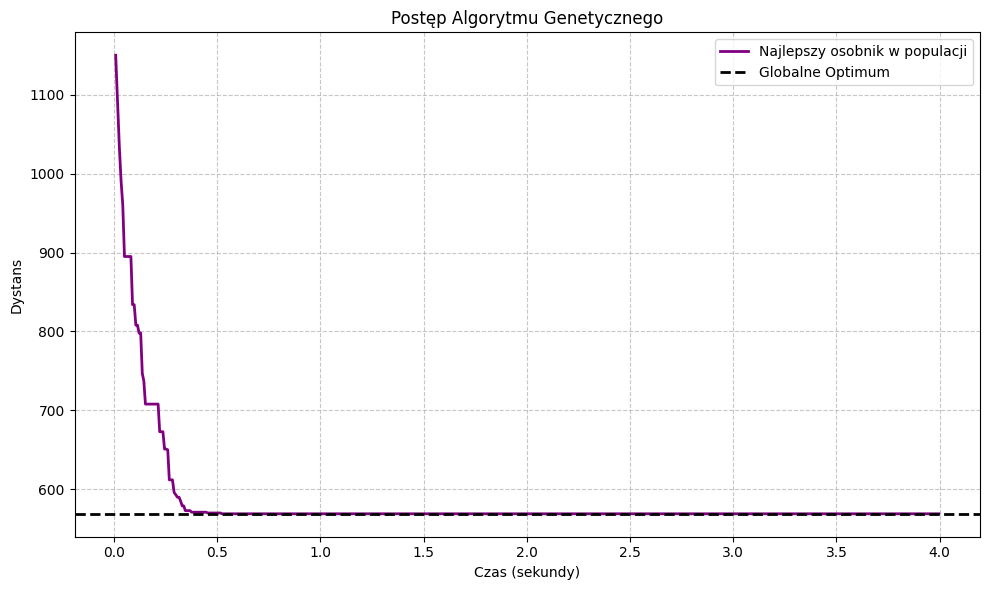

In [5]:
run_experiments(instances, solve_cvrp_ga, time_limit=40, population_size=400, generations=500, seed=42)

## Algorytm Hybrydowy

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Parametry GA: Populacja=400, Pokolenia=500, Limit czasu=10s
Uruchamianie algorytmu genetycznego
Czas wykonania: 3.95 s
Minimal tour: 569
Routes: [[1, 19, 20, 21, 23, 18, 15, 16, 17, 4, 3, 2, 7, 12, 13, 1], [1, 11, 14, 1], [1, 22, 5, 6, 9, 10, 8, 1]]

Krok 2: Uruchamianie solvera ILP
Czas wykonania: 19.97 s
Status: Optimal
Minimal tour: 569.0
Routes: [[1, 11, 14, 1], [1, 19, 20, 21, 23, 18, 15, 16, 17, 4, 3, 2, 7, 12, 13, 1], [1, 22, 5, 6, 9, 10, 8, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


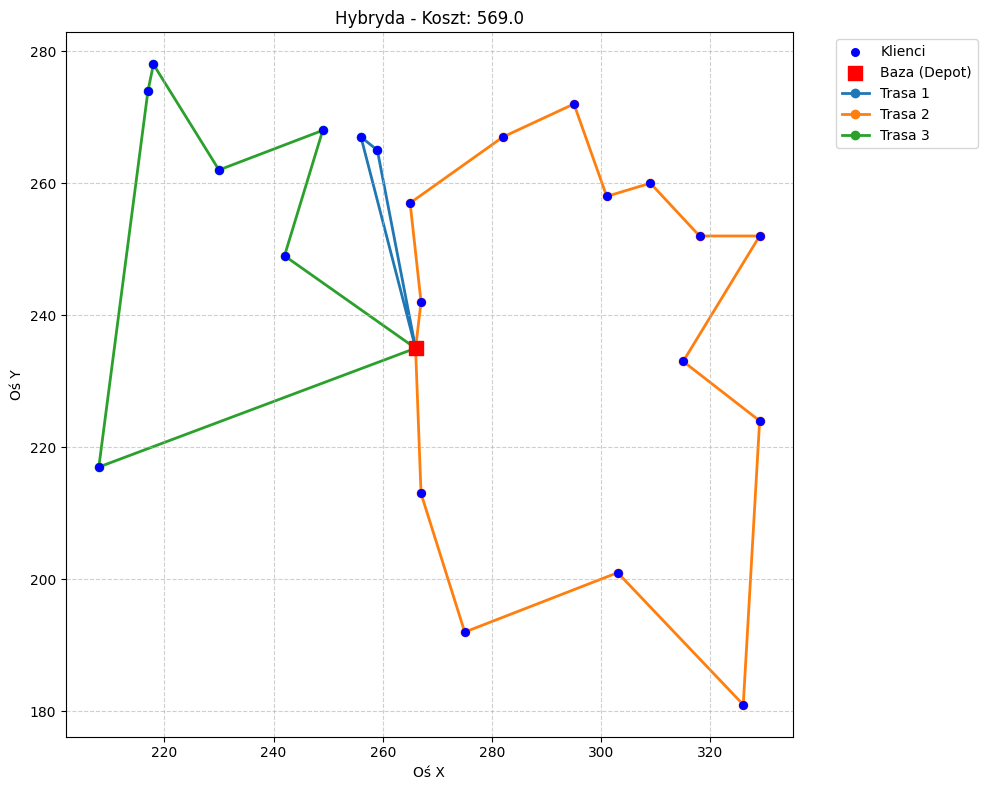

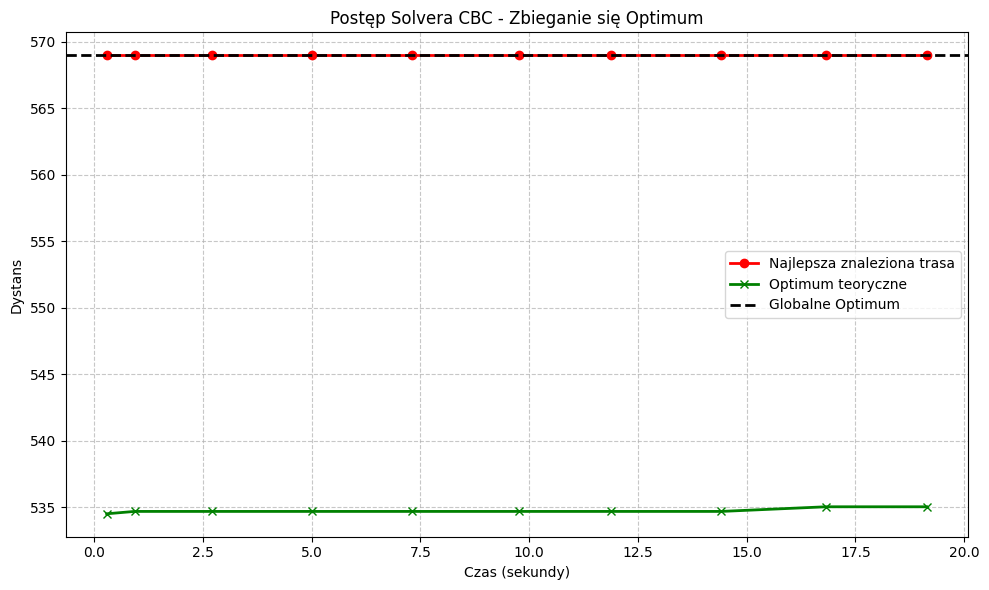

In [6]:
run_experiments(instances, solve_cvrp_hybrid, ga_time_limit=10, ilp_time_limit=20, population_size=500, generations=1000, seed=42)